In [ ]:
import os
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from matplotlib.patches import Patch

BASE      = "./data"
CSV_FILES = os.path.join(BASE, "CSV FILES")

print("Base      :", BASE)
print("CSV FILES :", CSV_FILES)



Base      : /Users/shravanivasa/Desktop/692/Project/Mob_compu_project/Group
CSV FILES : /Users/shravanivasa/Desktop/692/Project/Mob_compu_project/Group/CSV FILES


In [ ]:
def extract_features(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except:
        return None

    if len(df) < 2:
        return None

    # Normalize columns
    df.columns = df.columns.str.lower().str.strip()

    # Rename all known variants
    rename_map = {
        "frame.time"       : "time",
        "frame.time_epoch" : "time",
        "frame.len"        : "length",
        "frame.length"     : "length",
        "ip.src"           : "src_ip",
        "ip.dst"           : "dst_ip",
        "source"           : "src_ip",
        "destination"      : "dst_ip",
        "ip.proto"         : "protocol",
        "tcp.srcport"      : "src_port",
        "tcp.dstport"      : "dst_port",
        "udp.srcport"      : "src_port",
        "udp.dstport"      : "dst_port",
    }
    df = df.rename(columns=rename_map)

    for col in ["time", "length"]:
        if col not in df.columns:
            return None

    if "src_ip"   not in df.columns: df["src_ip"]   = "unknown"
    if "dst_ip"   not in df.columns: df["dst_ip"]   = "unknown"
    if "protocol" not in df.columns: df["protocol"] = "unknown"

    df["time"]   = pd.to_numeric(df["time"],   errors="coerce")
    df["length"] = pd.to_numeric(df["length"], errors="coerce")
    df = df.dropna(subset=["time", "length"])

    if len(df) < 2:
        return None

    df = df.sort_values("time").reset_index(drop=True)

    src_ip  = df["src_ip"].iloc[0]
    fwd     = df[df["src_ip"] == src_ip]["length"]
    bwd     = df[df["src_ip"] != src_ip]["length"]
    times   = df["time"].values
    iat_all = np.diff(times)
    fwd_t   = df[df["src_ip"] == src_ip]["time"].values
    bwd_t   = df[df["src_ip"] != src_ip]["time"].values
    fwd_iat = np.diff(fwd_t) if len(fwd_t) > 1 else np.array([0])
    bwd_iat = np.diff(bwd_t) if len(bwd_t) > 1 else np.array([0])

    def stats(arr, prefix):
        arr = np.array(arr) if len(arr) > 0 else np.array([0])
        return {
            f"{prefix}_mean"  : float(np.mean(arr)),
            f"{prefix}_std"   : float(np.std(arr)),
            f"{prefix}_min"   : float(np.min(arr)),
            f"{prefix}_max"   : float(np.max(arr)),
            f"{prefix}_p25"   : float(np.percentile(arr, 25)),
            f"{prefix}_median": float(np.median(arr)),
            f"{prefix}_p75"   : float(np.percentile(arr, 75)),
            f"{prefix}_p95"   : float(np.percentile(arr, 95)),
        }

    feats = {}
    feats.update(stats(fwd,     "fwd_pkt_size"))
    feats.update(stats(bwd,     "bwd_pkt_size"))
    feats.update(stats(iat_all, "iat"))
    feats.update(stats(fwd_iat, "fwd_iat"))
    feats.update(stats(bwd_iat, "bwd_iat"))

    fwd_bytes = fwd.sum() if len(fwd) > 0 else 0
    bwd_bytes = bwd.sum() if len(bwd) > 0 else 0
    fwd_pkts  = len(fwd)
    bwd_pkts  = len(bwd)

    feats["total_packets"]        = len(df)
    feats["fwd_packets"]          = fwd_pkts
    feats["bwd_packets"]          = bwd_pkts
    feats["fwd_bwd_packet_ratio"] = fwd_pkts  / (bwd_pkts  + 1e-9)
    feats["fwd_bwd_byte_ratio"]   = fwd_bytes / (bwd_bytes + 1e-9)
    feats["req_resp_size_ratio"]  = fwd_bytes / (len(df) * df["length"].mean() + 1e-9)
    feats["flow_duration"]        = float(times[-1] - times[0])
    feats["total_bytes"]          = int(df["length"].sum())
    feats["unique_dst_ips"]       = int(df["dst_ip"].nunique())
    feats["num_protocols"]        = int(df["protocol"].nunique())

    return feats

print("✅ extract_features ready!")



✅ extract_features ready!


In [ ]:
# DEBUG CELL
import pandas as pd

f = "/Users/shravanivasa/Desktop/692/Project/Mob_compu_project/Group/CSV FILES/genai/audio/chatgpt_2026_02_19_17_21_2026_02_19_17_30.csv"
df = pd.read_csv(f, on_bad_lines="skip")
df.columns = df.columns.str.lower().str.strip()
df = df.rename(columns={"frame.time": "time", "frame.len": "length", "ip.src": "src_ip", "ip.dst": "dst_ip"})

print("Columns:", list(df.columns))
print("Time sample:", df["time"].iloc[0])
print("Time type:", type(df["time"].iloc[0]))

# Try parsing
df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce").astype("int64") / 1e9
print("After parse - NaN count:", df["time"].isna().sum())
print("After parse - sample:", df["time"].iloc[0])
print("Length sample:", df["length"].iloc[0])
print("Total rows:", len(df))

Columns: ['frame.number', 'time', 'src_ip', 'dst_ip', 'ip.proto', 'length', 'tcp.srcport', 'tcp.dstport']
Time sample: 2026-02-19T17:21:39.795554000-0500
Time type: <class 'str'>
After parse - NaN count: 0
After parse - sample: 1771539699.7955542
Length sample: 66
Total rows: 592553


In [ ]:
import inspect
print(inspect.getsource(extract_features))

def extract_features(csv_path):
    try:
        df = pd.read_csv(csv_path)
    except:
        return None

    if len(df) < 2:
        return None

    # Normalize columns
    df.columns = df.columns.str.lower().str.strip()

    # Rename all known variants
    rename_map = {
        "frame.time"       : "time",
        "frame.time_epoch" : "time",
        "frame.len"        : "length",
        "frame.length"     : "length",
        "ip.src"           : "src_ip",
        "ip.dst"           : "dst_ip",
        "source"           : "src_ip",
        "destination"      : "dst_ip",
        "ip.proto"         : "protocol",
        "tcp.srcport"      : "src_port",
        "tcp.dstport"      : "dst_port",
        "udp.srcport"      : "src_port",
        "udp.dstport"      : "dst_port",
    }
    df = df.rename(columns=rename_map)

    for col in ["time", "length"]:
        if col not in df.columns:
            return None

    if "src_ip"   not in df.columns: df["src_ip"]   = "unknown"
    i

In [ ]:
# CELL 2 (FIXED v3) — Feature extraction function
import pandas as pd
import numpy as np

def extract_features(csv_path):
    try:
        df = pd.read_csv(csv_path, on_bad_lines="skip")
    except:
        return None

    if len(df) < 2:
        return None

    df.columns = df.columns.str.lower().str.strip()

    rename_map = {
        "frame.time"       : "time",
        "frame.time_epoch" : "time",
        "frame.len"        : "length",
        "frame.length"     : "length",
        "ip.src"           : "src_ip",
        "ip.dst"           : "dst_ip",
        "source"           : "src_ip",
        "destination"      : "dst_ip",
        "ip.proto"         : "protocol",
        "tcp.srcport"      : "src_port",
        "tcp.dstport"      : "dst_port",
        "udp.srcport"      : "src_port",
        "udp.dstport"      : "dst_port",
    }
    df = df.rename(columns=rename_map)

    for col in ["time", "length"]:
        if col not in df.columns:
            return None

    if "src_ip"   not in df.columns: df["src_ip"]   = "unknown"
    if "dst_ip"   not in df.columns: df["dst_ip"]   = "unknown"
    if "protocol" not in df.columns: df["protocol"] = "unknown"

    # Try numeric first, then parse as timestamp string
    time_numeric = pd.to_numeric(df["time"], errors="coerce")
    if time_numeric.isna().mean() > 0.5:
        df["time"] = pd.to_datetime(df["time"], utc=True, errors="coerce").astype("int64") / 1e9
    else:
        df["time"] = time_numeric

    df["length"] = pd.to_numeric(df["length"], errors="coerce")
    df = df.dropna(subset=["time", "length"])

    if len(df) < 2:
        return None

    df = df.sort_values("time").reset_index(drop=True)

    src_ip  = df["src_ip"].iloc[0]
    fwd     = df[df["src_ip"] == src_ip]["length"]
    bwd     = df[df["src_ip"] != src_ip]["length"]
    times   = df["time"].values
    iat_all = np.diff(times)
    fwd_t   = df[df["src_ip"] == src_ip]["time"].values
    bwd_t   = df[df["src_ip"] != src_ip]["time"].values
    fwd_iat = np.diff(fwd_t) if len(fwd_t) > 1 else np.array([0])
    bwd_iat = np.diff(bwd_t) if len(bwd_t) > 1 else np.array([0])

    def stats(arr, prefix):
        arr = np.array(arr) if len(arr) > 0 else np.array([0])
        return {
            f"{prefix}_mean"  : float(np.mean(arr)),
            f"{prefix}_std"   : float(np.std(arr)),
            f"{prefix}_min"   : float(np.min(arr)),
            f"{prefix}_max"   : float(np.max(arr)),
            f"{prefix}_p25"   : float(np.percentile(arr, 25)),
            f"{prefix}_median": float(np.median(arr)),
            f"{prefix}_p75"   : float(np.percentile(arr, 75)),
            f"{prefix}_p95"   : float(np.percentile(arr, 95)),
        }

    feats = {}
    feats.update(stats(fwd,     "fwd_pkt_size"))
    feats.update(stats(bwd,     "bwd_pkt_size"))
    feats.update(stats(iat_all, "iat"))
    feats.update(stats(fwd_iat, "fwd_iat"))
    feats.update(stats(bwd_iat, "bwd_iat"))

    fwd_bytes = fwd.sum() if len(fwd) > 0 else 0
    bwd_bytes = bwd.sum() if len(bwd) > 0 else 0
    fwd_pkts  = len(fwd)
    bwd_pkts  = len(bwd)

    feats["total_packets"]        = len(df)
    feats["fwd_packets"]          = fwd_pkts
    feats["bwd_packets"]          = bwd_pkts
    feats["fwd_bwd_packet_ratio"] = fwd_pkts  / (bwd_pkts  + 1e-9)
    feats["fwd_bwd_byte_ratio"]   = fwd_bytes / (bwd_bytes + 1e-9)
    feats["req_resp_size_ratio"]  = fwd_bytes / (len(df) * df["length"].mean() + 1e-9)
    feats["flow_duration"]        = float(times[-1] - times[0])
    feats["total_bytes"]          = int(df["length"].sum())
    feats["unique_dst_ips"]       = int(df["dst_ip"].nunique())
    feats["num_protocols"]        = int(df["protocol"].nunique())

    return feats

print("✅ extract_features ready!")

✅ extract_features ready!


In [ ]:
# CELL 3 — Build labels + extract features from ALL data
def get_app(filename):
    f = filename.lower()
    if "chatgpt" in f or "chat_gpt" in f: return "chatgpt"
    if "gemini"  in f:                    return "gemini"
    if "grok"    in f:                    return "grok"
    if "perplexity" in f:                 return "perplexity"
    if "youtube" in f:                    return "youtube"
    if "netflix" in f:                    return "netflix"
    if "amazon"  in f:                    return "amazon_prime"
    if "hulu"    in f:                    return "hulu"
    if "tiktok"  in f:                    return "tiktok"
    if "disney"  in f:                    return "disney"
    if "twitch"  in f:                    return "twitch"
    if "chrome"  in f:                    return "chrome"
    if "safari"  in f:                    return "safari"
    if "brave"   in f:                    return "brave"
    if "google"  in f:                    return "google"
    if "zoom"    in f:                    return "zoom"
    if "whatsapp" in f:                   return "whatsapp"
    if "instagram" in f:                  return "instagram"
    if "facetime" in f:                   return "facetime"
    if "call_of_duty" in f:               return "call_of_duty"
    if "pubg"    in f:                    return "pubg"
    if "fortnite" in f:                   return "fortnite"
    return filename.split("_")[0].lower()

BASE      = "/Users/shravanivasa/Desktop/692/Project/Mob_compu_project/Group"
CSV_FILES = os.path.join(BASE, "CSV FILES")

SOURCES = [
    (os.path.join(CSV_FILES, "genai",    "audio"),               "audio",               1),
    (os.path.join(CSV_FILES, "genai",    "text"),                "text",                1),
    (os.path.join(CSV_FILES, "genai",    "video"),               "video",               1),
    (os.path.join(CSV_FILES, "nongenai", "browsing"),            "browsing",            0),
    (os.path.join(CSV_FILES, "nongenai", "gaming"),              "gaming",              0),
    (os.path.join(CSV_FILES, "nongenai", "human_human_calling"), "audio_video_calling", 0),
    (os.path.join(CSV_FILES, "nongenai", "on_demand_streaming"), "on_demand_streaming", 0),
    (os.path.join(CSV_FILES, "nongenai", "others"),              "others",              0),
    (os.path.join(BASE, "GenAI_audio"),                          "audio",               1),
    (os.path.join(BASE, "GenAI_text"),                           "text",                1),
]

all_rows = []
for folder, subcategory, is_genai in SOURCES:
    if not os.path.exists(folder):
        print(f"  [MISSING] {folder}")
        continue

    csv_files = glob(os.path.join(folder, "*.csv"))
    print(f"  {os.path.basename(folder):25s} → {len(csv_files)} files")

    for csv_path in csv_files:
        filename = os.path.basename(csv_path)
        feats    = extract_features(csv_path)

        if feats is None:
            print(f"    [SKIP] {filename}")
            continue

        row = {
            "filename"   : filename,
            "category"   : "genai" if is_genai else "non_genai",
            "subcategory": subcategory,
            "app"        : get_app(filename),
            "is_genai"   : is_genai,
        }
        row.update(feats)
        all_rows.append(row)

features_df = pd.DataFrame(all_rows)
features_df = features_df.drop_duplicates(subset="filename").reset_index(drop=True)
features_df.to_csv(os.path.join(BASE, "features_all.csv"), index=False)

print(f"\n✅ Feature extraction done!")
print(f"Total samples  : {len(features_df)}")
print(f"GenAI  (1)     : {(features_df['is_genai']==1).sum()}")
print(f"NonGenAI (0)   : {(features_df['is_genai']==0).sum()}")
print(f"\nSubcategories:\n{features_df['subcategory'].value_counts()}")
print(f"\nApps:\n{features_df['app'].value_counts()}")

  audio                     → 22 files
  text                      → 52 files
  video                     → 8 files
    [SKIP] chatgpt_2025-10-15-19-24_2025-10-15-19-25.csv
  browsing                  → 5 files
  gaming                    → 2 files
  human_human_calling       → 6 files
  on_demand_streaming       → 2 files
    [SKIP] youtube_2025-12-02-23-58-42_2025-12-03-00-05-42.csv
  others                    → 1 files
  GenAI_audio               → 11 files
  GenAI_text                → 14 files

✅ Feature extraction done!
Total samples  : 99
GenAI  (1)     : 84
NonGenAI (0)   : 15

Subcategories:
subcategory
text                   54
audio                  23
video                   7
audio_video_calling     6
browsing                5
gaming                  2
on_demand_streaming     1
others                  1
Name: count, dtype: int64

Apps:
app
chatgpt         48
gemini          23
grok            11
perplexity       2
chrome           2
google           2
zoom             2
in

── Top 25: GenAI vs NonGenAI ──

   1. unique_dst_ips                 -0.510  (nongenai↑)
   2. bwd_pkt_size_median            -0.375  (nongenai↑)
   3. iat_p95                        +0.358  (genai↑)
   4. bwd_iat_std                    +0.341  (genai↑)
   5. iat_mean                       +0.335  (genai↑)
   6. bwd_iat_mean                   +0.332  (genai↑)
   7. iat_std                        +0.317  (genai↑)
   8. bwd_iat_min                    +0.309  (genai↑)
   9. bwd_packets                    -0.303  (nongenai↑)
  10. bwd_pkt_size_mean              -0.301  (nongenai↑)
  11. total_packets                  -0.300  (nongenai↑)
  12. bwd_pkt_size_p75               -0.299  (nongenai↑)
  13. bwd_pkt_size_max               -0.288  (nongenai↑)
  14. req_resp_size_ratio            +0.273  (genai↑)
  15. iat_max                        +0.253  (genai↑)
  16. bwd_iat_max                    +0.252  (genai↑)
  17. bwd_iat_p75                    +0.251  (genai↑)
  18. bwd_pkt_size_min      

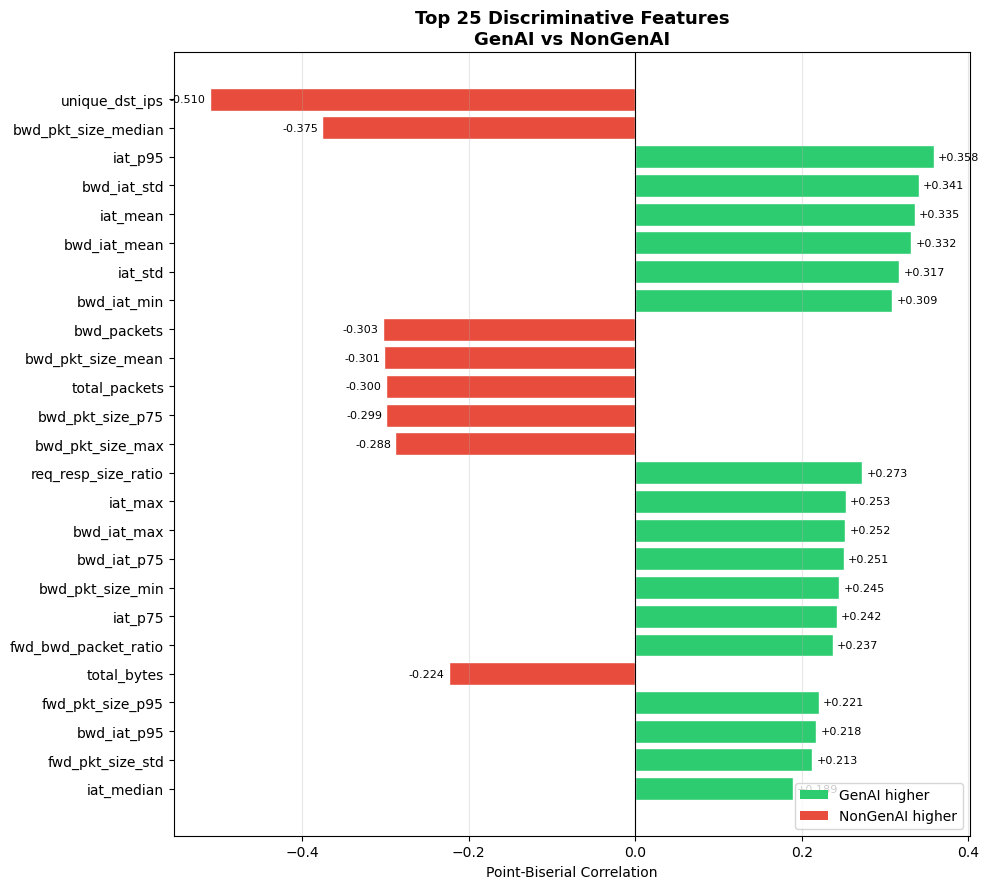

✅ Saved: top25_genai_vs_nongenai.png


In [ ]:
# CELL 4 — Top 25: GenAI vs NonGenAI
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from matplotlib.patches import Patch

df = pd.read_csv(os.path.join(BASE, "features_all.csv"))

meta     = ["filename", "category", "subcategory", "app", "is_genai"]
num_cols = [c for c in df.columns if c not in meta
            and df[c].dtype in [np.float64, np.int64]]

correlations = {}
for col in num_cols:
    vals = df[col].fillna(0)
    if vals.std() == 0: continue
    r, _ = pointbiserialr(df["is_genai"], vals)
    correlations[col] = r

corr_series = pd.Series(correlations).sort_values(key=abs, ascending=False)
top25 = corr_series.head(25)

print("── Top 25: GenAI vs NonGenAI ──\n")
for i, (feat, val) in enumerate(top25.items(), 1):
    print(f"  {i:2d}. {feat:<30} {val:+.3f}  ({'genai↑' if val>0 else 'nongenai↑'})")

colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in top25.values]
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top25.index[::-1], top25.values[::-1], color=colors[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Point-Biserial Correlation", fontsize=10)
ax.set_title("Top 25 Discriminative Features\nGenAI vs NonGenAI", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.legend(handles=[Patch(facecolor="#2ecc71", label="GenAI higher"),
                   Patch(facecolor="#e74c3c", label="NonGenAI higher")],
          fontsize=10, loc="lower right")
for val, bar in zip(top25.values[::-1], ax.patches):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "top25_genai_vs_nongenai.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: top25_genai_vs_nongenai.png")

── Top 25: GenAI Text vs Audio ──

   1. iat_mean                       +0.462  (text↑)
   2. bwd_iat_mean                   +0.450  (text↑)
   3. bwd_iat_std                    +0.449  (text↑)
   4. iat_p95                        +0.419  (text↑)
   5. iat_std                        +0.406  (text↑)
   6. bwd_pkt_size_p95               +0.394  (text↑)
   7. fwd_pkt_size_p75               -0.323  (audio↑)
   8. bwd_iat_p95                    +0.297  (text↑)
   9. fwd_bwd_byte_ratio             -0.293  (audio↑)
  10. total_packets                  -0.289  (audio↑)
  11. fwd_packets                    -0.286  (audio↑)
  12. fwd_pkt_size_median            -0.284  (audio↑)
  13. fwd_pkt_size_max               +0.269  (text↑)
  14. bwd_packets                    -0.264  (audio↑)
  15. bwd_iat_p75                    +0.263  (text↑)
  16. bwd_iat_max                    +0.259  (text↑)
  17. iat_median                     +0.259  (text↑)
  18. iat_max                        +0.255  (text↑)
  19.

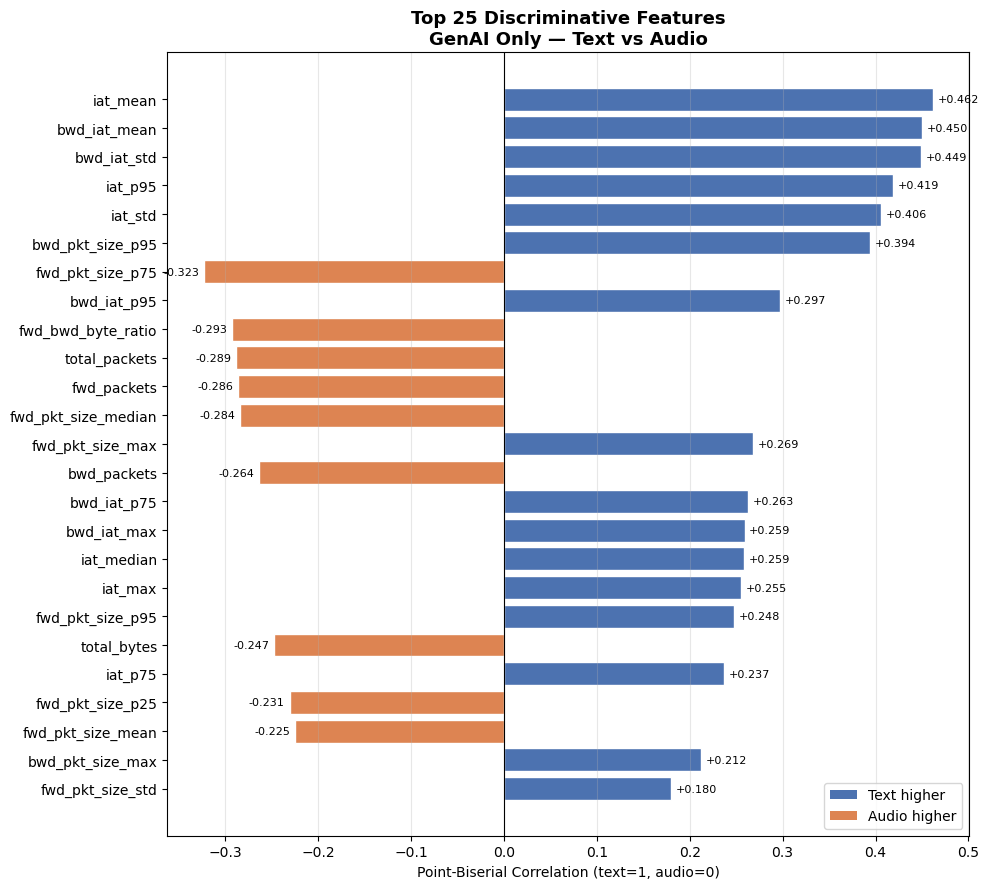

✅ Saved: top25_text_vs_audio.png


In [ ]:
# CELL 5 — Top 25: GenAI only — Text vs Audio
df_genai = df[df["is_genai"] == 1].copy()
df_genai["sub_label"] = (df_genai["subcategory"] == "text").astype(int)

correlations_sub = {}
for col in num_cols:
    vals = df_genai[col].fillna(0)
    if vals.std() == 0: continue
    r, _ = pointbiserialr(df_genai["sub_label"], vals)
    correlations_sub[col] = r

corr_sub  = pd.Series(correlations_sub).sort_values(key=abs, ascending=False)
top25_sub = corr_sub.head(25)

print("── Top 25: GenAI Text vs Audio ──\n")
for i, (feat, val) in enumerate(top25_sub.items(), 1):
    print(f"  {i:2d}. {feat:<30} {val:+.3f}  ({'text↑' if val>0 else 'audio↑'})")

colors2 = ["#4C72B0" if v > 0 else "#DD8452" for v in top25_sub.values]
fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(top25_sub.index[::-1], top25_sub.values[::-1], color=colors2[::-1], edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Point-Biserial Correlation (text=1, audio=0)", fontsize=10)
ax.set_title("Top 25 Discriminative Features\nGenAI Only — Text vs Audio", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
ax.legend(handles=[Patch(facecolor="#4C72B0", label="Text higher"),
                   Patch(facecolor="#DD8452", label="Audio higher")],
          fontsize=10, loc="lower right")
for val, bar in zip(top25_sub.values[::-1], ax.patches):
    ax.text(val + (0.005 if val >= 0 else -0.005),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va="center",
            ha="left" if val >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "top25_text_vs_audio.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: top25_text_vs_audio.png")

In [ ]:
# CELL 6 — Save top25 CSVs
df[["filename","category","subcategory","app","is_genai"] + top25.index.tolist()] \
    .to_csv(os.path.join(BASE, "features_top25_genai_vs_nongenai.csv"), index=False)

df_genai[["filename","category","subcategory","app","is_genai"] + top25_sub.index.tolist()] \
    .to_csv(os.path.join(BASE, "features_top25_text_vs_audio.csv"), index=False)

print("✅ Saved: features_top25_genai_vs_nongenai.csv")
print("✅ Saved: features_top25_text_vs_audio.csv")
print(f"\nFinal dataset summary:")
print(f"  Total   : {len(df)}")
print(f"  GenAI   : {(df['is_genai']==1).sum()}")
print(f"  NonGenAI: {(df['is_genai']==0).sum()}")

✅ Saved: features_top25_genai_vs_nongenai.csv
✅ Saved: features_top25_text_vs_audio.csv

Final dataset summary:
  Total   : 99
  GenAI   : 84
  NonGenAI: 15


── GenAI vs NonGenAI Classification Report ──

              precision    recall  f1-score   support

    NonGenAI       1.00      0.67      0.80         3
       GenAI       0.94      1.00      0.97        17

    accuracy                           0.95        20
   macro avg       0.97      0.83      0.89        20
weighted avg       0.95      0.95      0.95        20



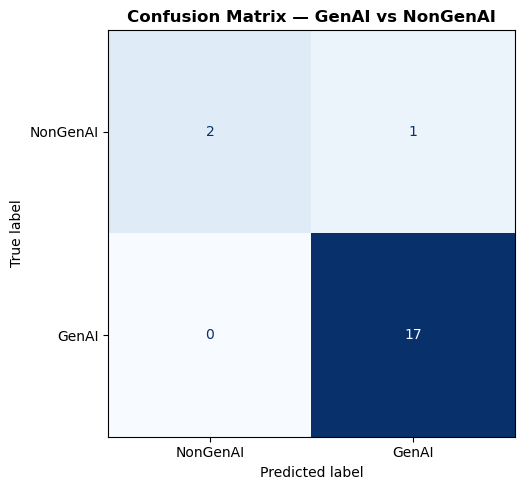


5-Fold Cross-Validation F1: 0.959 ± 0.039


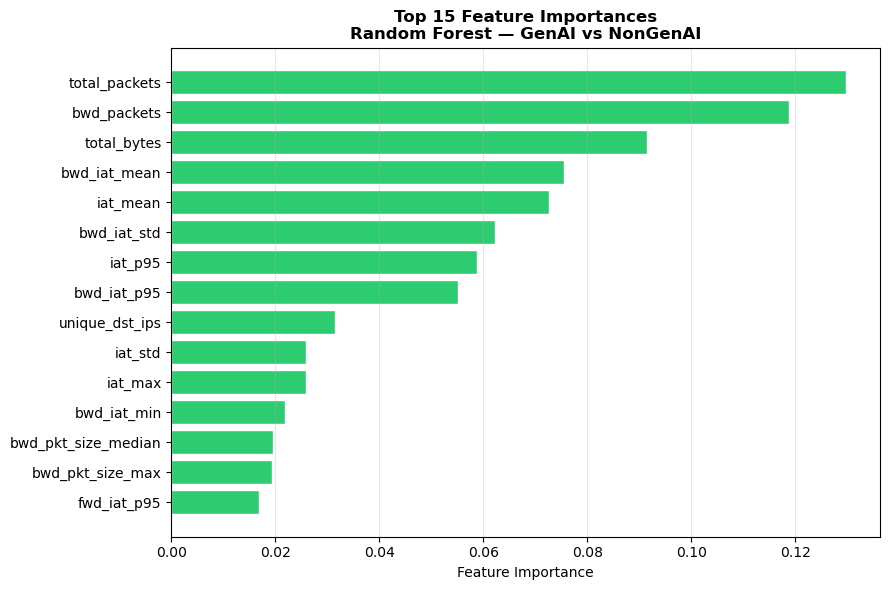

✅ Saved plots!


In [ ]:
# CELL 7 — Random Forest: GenAI vs NonGenAI
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv(os.path.join(BASE, "features_all.csv"))

meta     = ["filename", "category", "subcategory", "app", "is_genai"]
num_cols = [c for c in df.columns if c not in meta and df[c].dtype in [np.float64, np.int64]]

X = df[num_cols].fillna(0)
y = df["is_genai"]

# Train/test split — stratified to handle imbalance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# class_weight='balanced' handles the 84/15 imbalance
rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("── GenAI vs NonGenAI Classification Report ──\n")
print(classification_report(y_test, y_pred, target_names=["NonGenAI", "GenAI"]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NonGenAI", "GenAI"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — GenAI vs NonGenAI", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BASE, "rf_confusion_genai_vs_nongenai.png"), dpi=150, bbox_inches="tight")
plt.show()

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=cv, scoring="f1_weighted")
print(f"\n5-Fold Cross-Validation F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=num_cols).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances.index[::-1], importances.values[::-1], color="#2ecc71", edgecolor="white")
ax.set_xlabel("Feature Importance", fontsize=10)
ax.set_title("Top 15 Feature Importances\nRandom Forest — GenAI vs NonGenAI", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "rf_importance_genai_vs_nongenai.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved plots!")

── GenAI Text vs Audio Classification Report ──

              precision    recall  f1-score   support

       Audio       1.00      0.50      0.67         6
        Text       0.79      1.00      0.88        11

    accuracy                           0.82        17
   macro avg       0.89      0.75      0.77        17
weighted avg       0.86      0.82      0.80        17



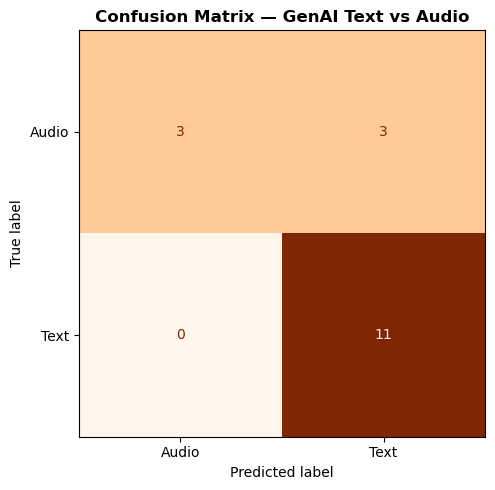


5-Fold Cross-Validation F1: 0.827 ± 0.096


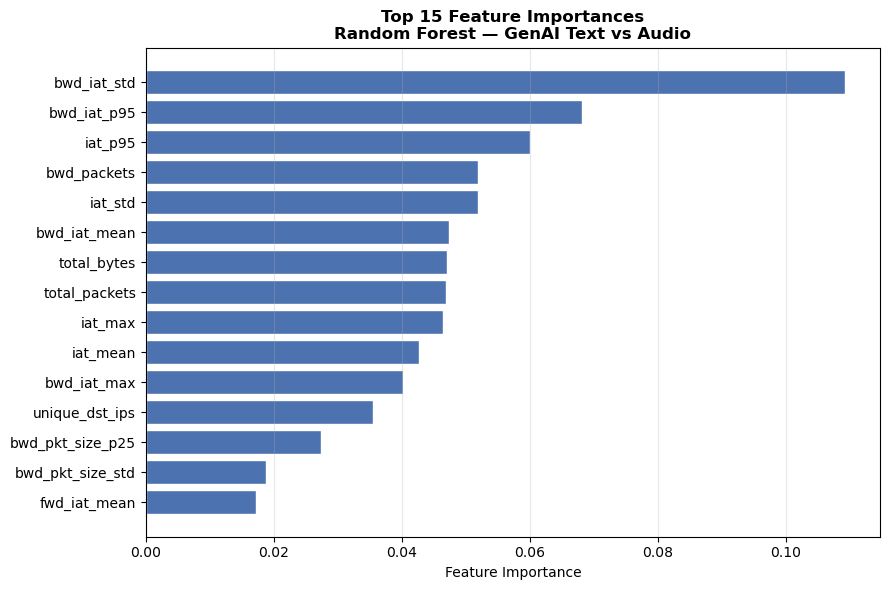

✅ Saved plots!


In [ ]:
# CELL 8 — Random Forest: GenAI Text vs Audio
df_genai = df[df["is_genai"] == 1].copy()
df_genai["sub_label"] = (df_genai["subcategory"] == "text").astype(int)

X2 = df_genai[num_cols].fillna(0)
y2 = df_genai["sub_label"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

rf2 = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf2.fit(X_train2, y_train2)
y_pred2 = rf2.predict(X_test2)

print("── GenAI Text vs Audio Classification Report ──\n")
print(classification_report(y_test2, y_pred2, target_names=["Audio", "Text"]))

# Confusion matrix
cm2 = confusion_matrix(y_test2, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=["Audio", "Text"])
fig, ax = plt.subplots(figsize=(6, 5))
disp2.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title("Confusion Matrix — GenAI Text vs Audio", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BASE, "rf_confusion_text_vs_audio.png"), dpi=150, bbox_inches="tight")
plt.show()

# Cross-validation
cv_scores2 = cross_val_score(rf2, X2, y2, cv=cv, scoring="f1_weighted")
print(f"\n5-Fold Cross-Validation F1: {cv_scores2.mean():.3f} ± {cv_scores2.std():.3f}")

# Feature importance
importances2 = pd.Series(rf2.feature_importances_, index=num_cols).sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances2.index[::-1], importances2.values[::-1], color="#4C72B0", edgecolor="white")
ax.set_xlabel("Feature Importance", fontsize=10)
ax.set_title("Top 15 Feature Importances\nRandom Forest — GenAI Text vs Audio", fontsize=12, fontweight="bold")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE, "rf_importance_text_vs_audio.png"), dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved plots!")